In [40]:
import matplotlib.pyplot as plt
from keras.layers import Input, Rescaling, ReLU, Dense, Conv2D, Flatten, Dropout, BatchNormalization, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, GlobalAveragePooling2D
from keras.utils import image_dataset_from_directory
from keras.models import Sequential
from keras.applications import VGG16
from keras.models import Model
from keras.optimizers import Adam

In [41]:
# 1. Load the Training Dataset (80%)
train_dataset = image_dataset_from_directory(
    directory='data/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=42,          # Must match the validation seed!
    validation_split=0.2,
    subset='training'
)

# 2. Load the Validation Dataset (20%)
val_dataset = image_dataset_from_directory(
    directory='data/data/',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,     # Keeps it consistent, though shuffling val data is optional
    seed=42,          # Must match the training seed!
    validation_split=0.2,
    subset='validation' # Changed to validation
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [42]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [43]:
vgg_base.trainable = False

x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation='softmax')(x)

In [44]:
vgg_model = Model(inputs=vgg_base.input, outputs=outputs)
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 21,139,781 (80.64 MB)

 Trainable params: 6,424,581 (24.51 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [45]:
history_of_vgg = vgg_model.fit(train_dataset, validation_data=val_dataset, epochs=5)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 459ms/step - accuracy: 0.7536 - loss: 0.7903 - val_accuracy: 0.8401 - val_loss: 0.6089
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 434ms/step - accuracy: 0.9369 - loss: 0.1888 - val_accuracy: 0.8598 - val_loss: 0.4280
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 435ms/step - accuracy: 0.9757 - loss: 0.0897 - val_accuracy: 0.8517 - val_loss: 0.4518
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 421ms/step - accuracy: 0.9896 - loss: 0.0534 - val_accuracy: 0.8505 - val_loss: 0.4300
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 427ms/step - accuracy: 0.9959 - loss: 0.0318 - val_accuracy: 0.8505 - val_loss: 0.4287


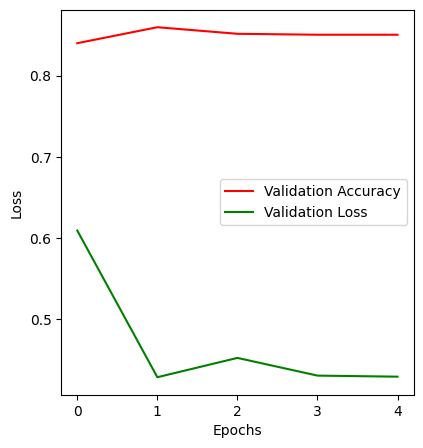

In [46]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_of_vgg.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.plot(history_of_vgg.history['val_loss'], label='Validation Loss', color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [47]:
vgg_base.trainable = True


for layer in vgg_base.layers[:-4]:
    layer.trainable = False

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5), # 100x smaller learning rate!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning last layers for 10 epochs...")
history = vgg_model.fit(train_dataset, validation_data=val_dataset, epochs=10)


Fine-tuning last layers for 10 epochs...
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.9959 - loss: 0.0190 - val_accuracy: 0.8552 - val_loss: 0.4239
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 480ms/step - accuracy: 0.9988 - loss: 0.0129 - val_accuracy: 0.8586 - val_loss: 0.4183
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 519ms/step - accuracy: 0.9977 - loss: 0.0150 - val_accuracy: 0.8679 - val_loss: 0.4180
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 499ms/step - accuracy: 0.9980 - loss: 0.0107 - val_accuracy: 0.8598 - val_loss: 0.4225
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 496ms/step - accuracy: 0.9986 - loss: 0.0097 - val_accuracy: 0.8598 - val_loss: 0.4192
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 504ms/step - accuracy: 0.9994 - loss: 0.0066 - val_accuracy: 0.8667 - val_loss: 0.4129
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 509ms/step - accuracy: 0.9986 - loss: 0.0085 - val_accuracy: 0.8702 - val_loss: 0.4010
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 518ms/step - 

In [48]:
for layer in vgg_base.layers:
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-6), # Extremely small learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning entire network for 5 epochs...")
final_history=vgg_model.fit(train_dataset, validation_data=val_dataset, epochs=5)


Fine-tuning entire network for 5 epochs...
Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9988 - loss: 0.0062 - val_accuracy: 0.8749 - val_loss: 0.4151
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9980 - loss: 0.0093 - val_accuracy: 0.8714 - val_loss: 0.4084
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 0.8760 - val_loss: 0.4119
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.8737 - val_loss: 0.4116
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.8725 - val_loss: 0.4093


In [49]:
import tensorflow as tf
import numpy as np

def make_vgg_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3", pred_index=None):
    # 1. Construct a graph that outputs the activations of the last conv layer and the final predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class with respect to the activations
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Calculate the gradients of the winning class neuron wrt the feature maps
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Global average pooling across the gradient tensor
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply the feature map channels by their calculated importance weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [50]:
import cv2

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Rescale heatmap values to standard 8-bit integers (0-255)
    heatmap = np.uint8(255 * heatmap)

    # Convert heatmap to a color Jet map (Red = Hot/Important, Blue = Cold)
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    jet = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    jet = cv2.resize(jet, (img.shape[1], img.shape[0]))

    # Blending the jet map directly over our original image
    superimposed_img = jet * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    return superimposed_img

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_187']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


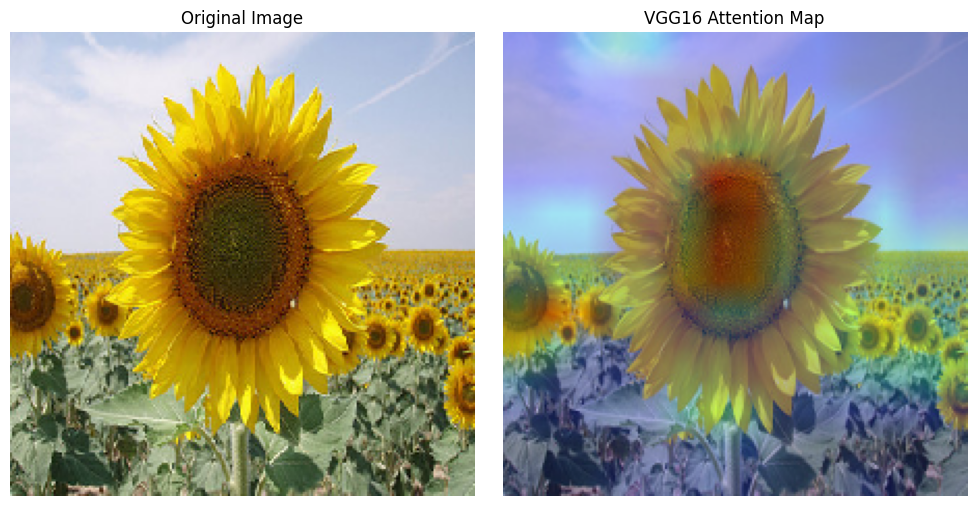

In [ ]:
import matplotlib.pyplot as plt

# 1. Set our image file path
sample_img_path = "data/data/sunflower/1022552002_2b93faf9e7_n.jpg"

# 2. Process image arrays for VGG16 structural matching
img = tf.keras.utils.load_img(sample_img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Reshapes to (1, 224, 224, 3)

# 3. Generate heatmap using our VGG16 function
# (Assumes our trained VGG16 model variable name is 'vgg_model')
vgg_heatmap = make_vgg_gradcam_heatmap(img_array, vgg_model)

# 4. Superimpose heatmap onto the flower image
vgg_gradcam_result = display_gradcam(sample_img_path, vgg_heatmap)

# 5. Plot the figures side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vgg_gradcam_result)
plt.title("VGG16 Attention Map")
plt.axis("off")

plt.tight_lawet()
plt.show()

### Observation
If we look closely at this VGG16 map alongside the MobileNetV2 one we generated earlier, we can see a brilliant architectural contrast:

VGG16 (This Map): Notice how the dark red and orange region is broader and more diffused. It covers the entire inner seed-disk of the sunflower and bleeds slightly out into the surrounding yellow petals. Because VGG16 relies on massive, deep stacks of traditional convolutions, its receptive field tends to aggregate larger, more continuous patches of context.

MobileNetV2 (Previous Map): MobileNetV2’s attention was likely tighter and highly localized on precise transition borders. That is the visual signature of its efficient depthwise separable layers and inverted bottlenecks focusing sharply on key discriminative textures.